# SqueezeNet 3-Class Image Classification with Keras

This notebook trains a SqueezeNet-style CNN for the 3 classes `Amine`, `Rifki`, and `Jakub` using the same center-crop preprocessing, reusable data pipeline, tuning, export, and INT8 quantization flow.


In [1]:
from pathlib import Path
from typing import List
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print('TensorFlow:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))


TensorFlow: 2.10.0
GPU available: True


In [2]:
SEED = 42
IMAGE_SIZE = (96, 96)
BATCH_SIZE = 16
EPOCHS = 10
CENTER_CROP_FRACTION = 0.75
CLASS_NAMES = ['Amine', 'Rifki', 'Jakub']
DATA_ROOT = Path('../data')
MODEL_PATH = Path('saved_model/squeezenet_3class.keras')

keras.utils.set_random_seed(SEED)

if not DATA_ROOT.exists():
    raise FileNotFoundError(f'Could not find dataset directory: {DATA_ROOT.resolve()}')

print('Data root:', DATA_ROOT.resolve())


Data root: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\data


In [3]:
def center_crop_array(array, crop_fraction=CENTER_CROP_FRACTION, image_size=IMAGE_SIZE):
    if not 0 < crop_fraction <= 1:
        raise ValueError('crop_fraction must be in the range (0, 1]')

    height, width = array.shape[:2]
    crop_height = max(1, int(height * crop_fraction))
    crop_width = max(1, int(width * crop_fraction))
    y0 = (height - crop_height) // 2
    x0 = (width - crop_width) // 2
    cropped = array[y0:y0 + crop_height, x0:x0 + crop_width]
    resized = tf.image.resize(cropped, image_size, method='bilinear')
    return resized.numpy().astype(np.float32)


def make_preprocess_fn(image_size=IMAGE_SIZE, crop_fraction=CENTER_CROP_FRACTION):
    def preprocess_fn(array):
        return preprocess_input(center_crop_array(array, crop_fraction=crop_fraction, image_size=image_size))
    return preprocess_fn


preprocess_final_input = make_preprocess_fn()


In [4]:
def collect_split_dataframe(data_root: Path, class_names: List[str], split: str) -> pd.DataFrame:
    records = []
    valid_ext = {'.png', '.jpg', '.jpeg', '.bmp'}

    for class_name in class_names:
        split_dir = data_root / class_name / split
        if not split_dir.exists():
            raise FileNotFoundError(f'Missing split directory: {split_dir}')

        for file_path in sorted(split_dir.iterdir()):
            if file_path.is_file() and file_path.suffix.lower() in valid_ext:
                records.append({'filepath': str(file_path), 'label': class_name})

    if not records:
        raise ValueError(f'No images found for split={split!r}')

    df = pd.DataFrame(records)
    return df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)


train_df = collect_split_dataframe(DATA_ROOT, CLASS_NAMES, 'train')
test_df = collect_split_dataframe(DATA_ROOT, CLASS_NAMES, 'test')

display(train_df.head())
print('Train samples:', len(train_df))
print(train_df['label'].value_counts().sort_index())
print()
print('Test samples:', len(test_df))
print(test_df['label'].value_counts().sort_index())


,filepath,label
0,..\data\Jakub\train\image_20260314_150704.png,Jakub
1,..\data\Amine\train\image_20260321_204014_brig...,Amine
2,..\data\Jakub\train\image_20260314_145634_comp...,Jakub
3,..\data\Rifki\train\image_20260312_074812_occl...,Rifki
4,..\data\Rifki\train\image_20260305_130316_hfli...,Rifki


Train samples: 2160
label
Amine    720
Jakub    720
Rifki    720
Name: count, dtype: int64

Test samples: 540
label
Amine    180
Jakub    180
Rifki    180
Name: count, dtype: int64


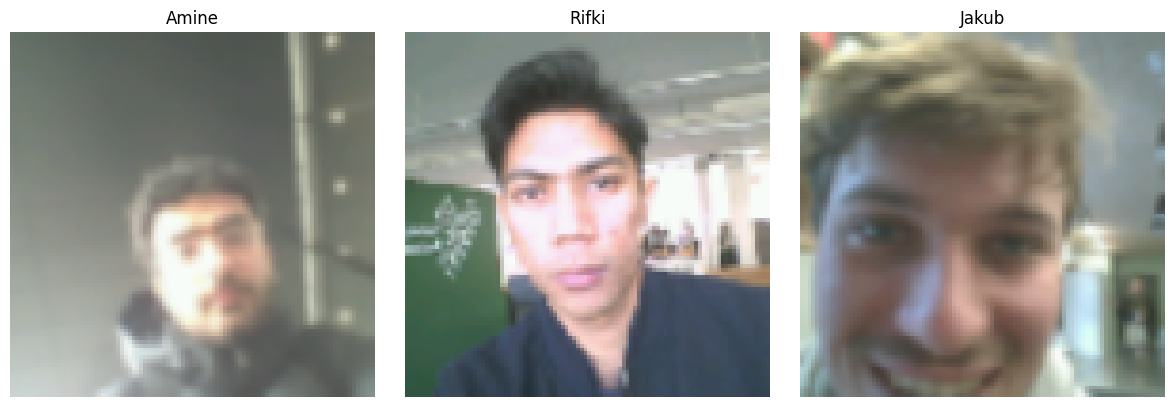

In [5]:
sample_paths = []
for class_name in CLASS_NAMES:
    class_rows = train_df[train_df['label'] == class_name]
    sample_paths.append(class_rows.sample(1, random_state=SEED).iloc[0]['filepath'])

plt.figure(figsize=(12, 4))
for i, image_path in enumerate(sample_paths, start=1):
    image = keras.utils.load_img(image_path, target_size=IMAGE_SIZE, keep_aspect_ratio=True)
    image_array = keras.utils.img_to_array(image)
    cropped_image = center_crop_array(image_array).astype(np.uint8)
    plt.subplot(1, len(sample_paths), i)
    plt.imshow(cropped_image)
    plt.title(Path(image_path).parts[-3])
    plt.axis('off')
plt.tight_layout()
plt.show()


In [6]:
def make_data_generators(image_size=IMAGE_SIZE, crop_fraction=CENTER_CROP_FRACTION):
    preprocess_fn = make_preprocess_fn(image_size=image_size, crop_fraction=crop_fraction)

    train_datagen = keras.preprocessing.image.ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        validation_split=0.2,
        rotation_range=12,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        brightness_range=(0.9, 1.1),
        horizontal_flip=True,
    )

    test_datagen = keras.preprocessing.image.ImageDataGenerator(
        preprocessing_function=preprocess_fn,
    )

    train_gen = train_datagen.flow_from_dataframe(
        dataframe=train_df,
        x_col='filepath',
        y_col='label',
        target_size=image_size,
        keep_aspect_ratio=True,
        class_mode='categorical',
        classes=CLASS_NAMES,
        subset='training',
        batch_size=BATCH_SIZE,
        seed=SEED,
        shuffle=True,
    )

    val_gen = train_datagen.flow_from_dataframe(
        dataframe=train_df,
        x_col='filepath',
        y_col='label',
        target_size=image_size,
        keep_aspect_ratio=True,
        class_mode='categorical',
        classes=CLASS_NAMES,
        subset='validation',
        batch_size=BATCH_SIZE,
        seed=SEED,
        shuffle=False,
    )

    test_gen = test_datagen.flow_from_dataframe(
        dataframe=test_df,
        x_col='filepath',
        y_col='label',
        target_size=image_size,
        keep_aspect_ratio=True,
        class_mode='categorical',
        classes=CLASS_NAMES,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    return train_gen, val_gen, test_gen


train_gen, val_gen, test_gen = make_data_generators()
print('Class indices:', train_gen.class_indices)


Found 1728 validated image filenames belonging to 3 classes.
Found 432 validated image filenames belonging to 3 classes.
Found 540 validated image filenames belonging to 3 classes.
Class indices: {'Amine': 0, 'Rifki': 1, 'Jakub': 2}


In [7]:
def scaled_filters(filters: int, width_multiplier: float) -> int:
    return max(1, int(round(filters * width_multiplier)))


def fire_module(x, squeeze_filters: int, expand_filters: int, name: str, l2_strength: float):
    regularizer = keras.regularizers.l2(l2_strength) if l2_strength else None
    squeezed = layers.Conv2D(
        squeeze_filters,
        (1, 1),
        activation='relu',
        padding='same',
        kernel_regularizer=regularizer,
        name=f'{name}_squeeze',
    )(x)
    expand_1x1 = layers.Conv2D(
        expand_filters,
        (1, 1),
        activation='relu',
        padding='same',
        kernel_regularizer=regularizer,
        name=f'{name}_expand1x1',
    )(squeezed)
    expand_3x3 = layers.Conv2D(
        expand_filters,
        (3, 3),
        activation='relu',
        padding='same',
        kernel_regularizer=regularizer,
        name=f'{name}_expand3x3',
    )(squeezed)
    return layers.Concatenate(name=f'{name}_concat')([expand_1x1, expand_3x3])


def build_squeezenet_model(config: dict, model_name: str = 'SqueezeNet3Class') -> keras.Model:
    image_size = tuple(config.get('image_size', IMAGE_SIZE))
    width_multiplier = float(config['width_multiplier'])
    dropout = float(config['dropout'])
    learning_rate = float(config['learning_rate'])
    l2_strength = float(config['l2'])
    regularizer = keras.regularizers.l2(l2_strength) if l2_strength else None

    def sf(filters: int) -> int:
        return scaled_filters(filters, width_multiplier)

    inputs = keras.Input(shape=image_size + (3,))
    x = layers.Conv2D(sf(64), (3, 3), strides=2, padding='same', activation='relu', kernel_regularizer=regularizer, name='conv1')(inputs)
    x = layers.MaxPooling2D(pool_size=(3, 3), strides=2, padding='same', name='maxpool1')(x)

    x = fire_module(x, sf(16), sf(64), 'fire2', l2_strength)
    x = fire_module(x, sf(16), sf(64), 'fire3', l2_strength)
    x = layers.MaxPooling2D(pool_size=(3, 3), strides=2, padding='same', name='maxpool3')(x)

    x = fire_module(x, sf(32), sf(128), 'fire4', l2_strength)
    x = fire_module(x, sf(32), sf(128), 'fire5', l2_strength)
    x = layers.MaxPooling2D(pool_size=(3, 3), strides=2, padding='same', name='maxpool5')(x)

    x = fire_module(x, sf(48), sf(192), 'fire6', l2_strength)
    x = fire_module(x, sf(48), sf(192), 'fire7', l2_strength)
    x = fire_module(x, sf(64), sf(256), 'fire8', l2_strength)
    x = fire_module(x, sf(64), sf(256), 'fire9', l2_strength)

    x = layers.Dropout(dropout, name='dropout')(x)
    x = layers.Conv2D(
        len(CLASS_NAMES),
        (1, 1),
        padding='same',
        activation='relu',
        kernel_regularizer=regularizer,
        name='classifier_conv',
    )(x)
    x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
    outputs = layers.Activation('softmax', name='predictions')(x)

    model = keras.Model(inputs, outputs, name=model_name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model


## Hyperparameter Tuning

Run this section before final training to compare SqueezeNet width, regularization, input size, and center-crop settings.


In [8]:
TUNING_EPOCHS = 8

TUNING_CONFIGS = [
    {'image_size': (128, 128), 'crop_fraction': 0.75, 'width_multiplier': 0.75, 'dropout': 0.3, 'l2': 0.0, 'learning_rate': 1e-3},
    {'image_size': (160, 160), 'crop_fraction': 0.75, 'width_multiplier': 1.0, 'dropout': 0.4, 'l2': 0.0, 'learning_rate': 1e-3},
    {'image_size': (192, 192), 'crop_fraction': 0.75, 'width_multiplier': 1.0, 'dropout': 0.4, 'l2': 0.0, 'learning_rate': 1e-3},
    {'image_size': (160, 160), 'crop_fraction': 0.70, 'width_multiplier': 1.0, 'dropout': 0.4, 'l2': 1e-4, 'learning_rate': 5e-4},
    {'image_size': (192, 192), 'crop_fraction': 0.80, 'width_multiplier': 1.25, 'dropout': 0.4, 'l2': 1e-4, 'learning_rate': 5e-4},
]


tuning_results = []
for run_id, config in enumerate(TUNING_CONFIGS, start=1):
    print(f'\nTuning run {run_id}/{len(TUNING_CONFIGS)}: {config}')
    keras.backend.clear_session()
    keras.utils.set_random_seed(SEED)

    tuning_train_gen, tuning_val_gen, _ = make_data_generators(
        image_size=tuple(config['image_size']),
        crop_fraction=float(config['crop_fraction']),
    )
    tuning_model = build_squeezenet_model(config, model_name=f'SqueezeNet3Class_Tuning_{run_id}')
    print('Model summary before training:')
    tuning_model.summary()

    tuning_history = tuning_model.fit(
        tuning_train_gen,
        validation_data=tuning_val_gen,
        epochs=TUNING_EPOCHS,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
        ],
        verbose=1,
    )

    best_val_accuracy = max(tuning_history.history['val_accuracy'])
    best_val_loss = min(tuning_history.history['val_loss'])
    tuning_results.append({
        'run_id': run_id,
        **config,
        'image_size': f'{config["image_size"][0]}x{config["image_size"][1]}',
        'best_val_accuracy': best_val_accuracy,
        'best_val_loss': best_val_loss,
        'epochs_run': len(tuning_history.history['loss']),
    })


tuning_df = pd.DataFrame(tuning_results).sort_values(
    ['best_val_accuracy', 'best_val_loss'],
    ascending=[False, True],
).reset_index(drop=True)

display(tuning_df)
best_config = tuning_df.iloc[0].to_dict()
best_config['image_size'] = tuple(int(part) for part in best_config['image_size'].split('x'))
print('Best config:')
print(best_config)



Tuning run 1/5: {'image_size': (128, 128), 'crop_fraction': 0.75, 'width_multiplier': 0.75, 'dropout': 0.3, 'l2': 0.0, 'learning_rate': 0.001}
Found 1728 validated image filenames belonging to 3 classes.
Found 432 validated image filenames belonging to 3 classes.
Found 540 validated image filenames belonging to 3 classes.
Model summary before training:
Model: "SqueezeNet3Class_Tuning_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1 (Conv2D)                 (None, 64, 64, 48)   1344        ['input_1[0][0]']                
               

,run_id,image_size,crop_fraction,width_multiplier,dropout,l2,learning_rate,best_val_accuracy,best_val_loss,epochs_run
0,1,128x128,0.75,0.75,0.3,0.0000,0.0010,0.351852,1.098612,4
1,2,160x160,0.75,1.00,0.4,0.0000,0.0010,0.351852,1.098612,4
2,3,192x192,0.75,1.00,0.4,0.0000,0.0010,0.351852,1.098612,4
3,5,192x192,0.80,1.25,0.4,0.0001,0.0005,0.351852,1.098623,8
4,4,160x160,0.70,1.00,0.4,0.0001,0.0005,0.351852,1.098633,8


Best config:
{'run_id': 1, 'image_size': (128, 128), 'crop_fraction': 0.75, 'width_multiplier': 0.75, 'dropout': 0.3, 'l2': 0.0, 'learning_rate': 0.001, 'best_val_accuracy': 0.35185185074806213, 'best_val_loss': 1.0986119508743286, 'epochs_run': 4}


In [8]:
DEFAULT_FINAL_CONFIG = {
    'image_size': IMAGE_SIZE,
    'crop_fraction': CENTER_CROP_FRACTION,
    'width_multiplier': 1.0,
    'dropout': 0.4,
    'l2': 0.0,
    'learning_rate': 1e-3,
}

FINAL_CONFIG = dict(DEFAULT_FINAL_CONFIG)
if 'best_config' in globals():
    FINAL_CONFIG.update({
        'image_size': tuple(best_config['image_size']),
        'crop_fraction': float(best_config['crop_fraction']),
        'width_multiplier': float(best_config['width_multiplier']),
        'dropout': float(best_config['dropout']),
        'l2': float(best_config['l2']),
        'learning_rate': float(best_config['learning_rate']),
    })

print('Final training config:', FINAL_CONFIG)
keras.backend.clear_session()
keras.utils.set_random_seed(SEED)

IMAGE_SIZE = tuple(FINAL_CONFIG['image_size'])
preprocess_final_input = make_preprocess_fn(
    image_size=IMAGE_SIZE,
    crop_fraction=FINAL_CONFIG['crop_fraction'],
)
train_gen, val_gen, test_gen = make_data_generators(
    image_size=IMAGE_SIZE,
    crop_fraction=FINAL_CONFIG['crop_fraction'],
)

model = build_squeezenet_model(FINAL_CONFIG)
model.summary()

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    keras.callbacks.ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', save_best_only=True),
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
)

model = keras.models.load_model(MODEL_PATH)


Final training config: {'image_size': (96, 96), 'crop_fraction': 0.75, 'width_multiplier': 1.0, 'dropout': 0.4, 'l2': 0.0, 'learning_rate': 0.001}
Found 1728 validated image filenames belonging to 3 classes.
Found 432 validated image filenames belonging to 3 classes.
Found 540 validated image filenames belonging to 3 classes.
Model: "SqueezeNet3Class"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 96, 96, 3)]  0           []                               
                                                                                                  
 conv1 (Conv2D)                 (None, 48, 48, 64)   1792        ['input_1[0][0]']                
                                                                                                  
 maxpool1 (MaxPooling2D)        (None, 24, 24, 64)  

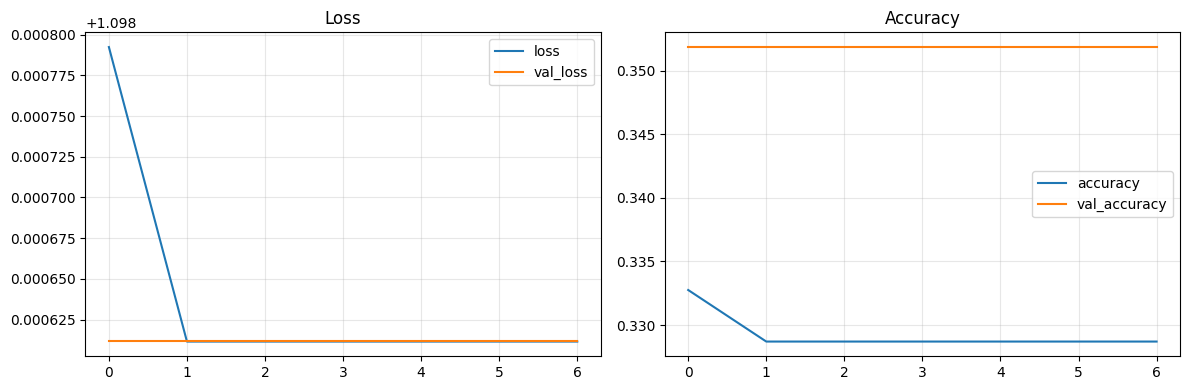

In [10]:
history_df = pd.DataFrame(history.history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

history_df[['loss', 'val_loss']].plot(ax=axes[0], title='Loss')
history_df[['accuracy', 'val_accuracy']].plot(ax=axes[1], title='Accuracy')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Test loss: 1.0986
Test accuracy: 0.3333

              precision    recall  f1-score   support

       Amine       0.33      1.00      0.50       180
       Rifki       0.00      0.00      0.00       180
       Jakub       0.00      0.00      0.00       180

    accuracy                           0.33       540
   macro avg       0.11      0.33      0.17       540
weighted avg       0.11      0.33      0.17       540



c:\Users\Rifki\.conda\envs\TF\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rifki\.conda\envs\TF\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rifki\.conda\envs\TF\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


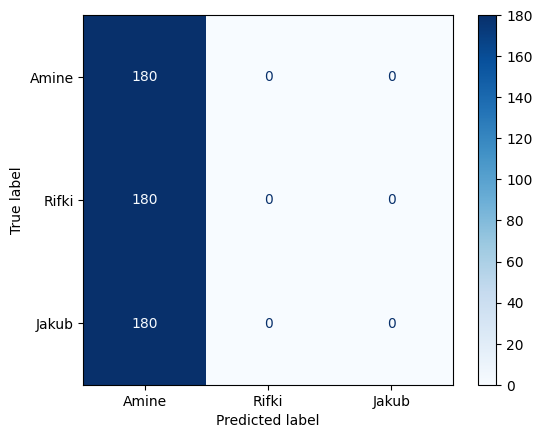

In [11]:
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

probabilities = model.predict(test_gen, verbose=0)
y_pred = np.argmax(probabilities, axis=1)
y_true = test_gen.classes

print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', values_format='d')
plt.show()


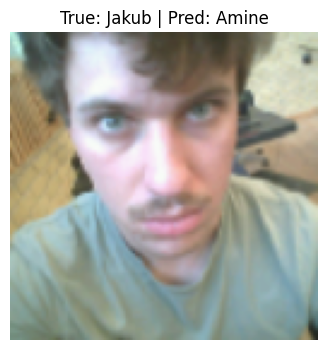

Amine: 0.3333
Rifki: 0.3333
Jakub: 0.3333

Saved model to: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\saved_model\squeezenet_3class.keras


In [12]:
index_to_class = {v: k for k, v in train_gen.class_indices.items()}
random_row = test_df.sample(1, random_state=random.randint(0, 10_000)).iloc[0]
sample_path = random_row['filepath']

image = keras.utils.load_img(sample_path, target_size=IMAGE_SIZE, keep_aspect_ratio=True)
array = keras.utils.img_to_array(image)
cropped_image = center_crop_array(array, crop_fraction=FINAL_CONFIG['crop_fraction'], image_size=IMAGE_SIZE).astype(np.uint8)
array = preprocess_final_input(array)
prediction = model.predict(np.expand_dims(array, axis=0), verbose=0)[0]
if np.max(prediction) < 0.95:
    print('Warning: Low confidence prediction (max score < 0.95)')
predicted_class = index_to_class[int(np.argmax(prediction))]

plt.figure(figsize=(4, 4))
plt.imshow(cropped_image)
plt.title(f'True: {random_row["label"]} | Pred: {predicted_class}')
plt.axis('off')
plt.show()

for class_name, score in zip(CLASS_NAMES, prediction):
    print(f'{class_name}: {score:.4f}')

print()
print('Saved model to:', MODEL_PATH.resolve())


## Export Training Subset

This section saves the preprocessed training subset used by SqueezeNet to `saved_model/x_train_squeezenet.npy` and `saved_model/y_train_squeezenet.npy` for later quantization.


In [13]:
VALIDATION_SPLIT = 0.2
FINAL_IMAGE_SIZE = tuple(globals().get('FINAL_CONFIG', {}).get('image_size', IMAGE_SIZE))
FINAL_CROP_FRACTION = float(globals().get('FINAL_CONFIG', {}).get('crop_fraction', CENTER_CROP_FRACTION))
X_TRAIN_PATH = MODEL_PATH.parent / f'x_train_squeezenet_{FINAL_IMAGE_SIZE[0]}.npy'
Y_TRAIN_PATH = MODEL_PATH.parent / f'y_train_squeezenet_{FINAL_IMAGE_SIZE[0]}.npy'


def make_training_subset(train_df: pd.DataFrame) -> pd.DataFrame:
    split_index = int(len(train_df) * VALIDATION_SPLIT)
    return train_df.iloc[split_index:].reset_index(drop=True)


def load_and_preprocess_images(train_subset: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    class_to_index = {name: idx for idx, name in enumerate(CLASS_NAMES)}
    preprocess_fn = make_preprocess_fn(image_size=FINAL_IMAGE_SIZE, crop_fraction=FINAL_CROP_FRACTION)

    x_train = []
    y_train = []

    for row in train_subset.itertuples(index=False):
        image = keras.utils.load_img(row.filepath, target_size=FINAL_IMAGE_SIZE, keep_aspect_ratio=True)
        array = keras.utils.img_to_array(image).astype(np.float32)
        array = preprocess_fn(array)

        x_train.append(array)
        y_train.append(class_to_index[row.label])

    return np.stack(x_train).astype(np.float32), np.array(y_train, dtype=np.int32)


MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
train_subset = make_training_subset(train_df)
x_train, y_train = load_and_preprocess_images(train_subset)

np.save(X_TRAIN_PATH, x_train)
np.save(Y_TRAIN_PATH, y_train)

print(f'Export image size: {FINAL_IMAGE_SIZE}')
print(f'Saved training subset: {len(train_subset)} images')
print(f'x_train shape: {x_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'Saved: {X_TRAIN_PATH.resolve()}')
print(f'Saved: {Y_TRAIN_PATH.resolve()}')


Saved training subset: 1728 images
x_train shape: (1728, 128, 128, 3)
y_train shape: (1728,)
Saved: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\saved_model\x_train_squeezenet.npy
Saved: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\saved_model\y_train_squeezenet.npy


## Quantization

Export the trained SqueezeNet model to full INT8 TensorFlow Lite, generate C/H artifacts, and evaluate the quantized model using the same center-crop preprocessing and selected final input size.


In [14]:
import os
from utils.export_tflite import write_model_c_file, write_model_h_file

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.get_logger().setLevel('ERROR')

SCRIPT_DIR = Path.cwd()
QUANTIZED_MODEL_DIR = SCRIPT_DIR / 'quantized_model'
GEN_DIR = SCRIPT_DIR / 'gen'
KERAS_MODEL_PATH = MODEL_PATH
EXPORT_IMAGE_SIZE = tuple(globals().get('FINAL_CONFIG', {}).get('image_size', IMAGE_SIZE))
CALIBRATION_DATA_PATH = MODEL_PATH.parent / f'x_train_squeezenet_{EXPORT_IMAGE_SIZE[0]}.npy'
SQUEEZENET_TFLITE_MODEL_PATH = QUANTIZED_MODEL_DIR / 'squeezenet_3class_int8.tflite'
SQUEEZENET_MODEL_C_PATH = GEN_DIR / 'squeezenet_model.c'
SQUEEZENET_MODEL_H_PATH = GEN_DIR / 'squeezenet_model.h'
REPRESENTATIVE_DATASET_SAMPLES = 512
NUM_CLASSES = len(CLASS_NAMES)
CLASS_TO_INDEX = {name: idx for idx, name in enumerate(CLASS_NAMES)}

print('Keras model:', KERAS_MODEL_PATH.resolve())
print('Calibration data:', CALIBRATION_DATA_PATH.resolve())
print('TFLite output:', SQUEEZENET_TFLITE_MODEL_PATH.resolve())


Keras model: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\saved_model\squeezenet_3class.keras
Calibration data: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\saved_model\x_train_squeezenet.npy
TFLite output: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\quantized_model\squeezenet_3class_int8.tflite


In [15]:
def representative_indices(num_samples: int, max_samples: int = REPRESENTATIVE_DATASET_SAMPLES) -> np.ndarray:
    if num_samples <= 0:
        raise ValueError('Representative dataset requires at least one sample.')
    if num_samples <= max_samples:
        return np.arange(num_samples, dtype=np.int32)
    return np.linspace(0, num_samples - 1, num=max_samples, dtype=np.int32)


def export_model_to_tflite(model: keras.Model, x_train: np.ndarray) -> bytes:
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    def representative_dataset():
        for i in representative_indices(len(x_train)):
            yield [x_train[i:i + 1].astype(np.float32)]

    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()


def resolve_model_img_size(model: keras.Model) -> int:
    input_shape = model.input_shape[0] if isinstance(model.input_shape, list) else model.input_shape
    if len(input_shape) != 4:
        raise ValueError(f'Expected 4D model input shape, got {input_shape}')

    height, width, channels = input_shape[1:]
    if None in (height, width, channels):
        raise ValueError(f'Model input shape must be fully defined, got {input_shape}')
    if channels != 3 or height != width:
        raise ValueError(f'Expected square RGB input, got {input_shape}')
    return int(height)


def export_artifacts(tflite_model: bytes, img_size: int):
    QUANTIZED_MODEL_DIR.mkdir(exist_ok=True)
    GEN_DIR.mkdir(exist_ok=True)

    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    input_scale, input_zero_point = input_details['quantization']
    output_scale, output_zero_point = output_details['quantization']

    defines = {
        'IMG_SIZE': img_size,
        'NUM_CLASSES': NUM_CLASSES,
        'INPUT_SCALE': f'{input_scale}f',
        'INPUT_ZERO_POINT': input_zero_point,
        'OUTPUT_SCALE': f'{output_scale}f',
        'OUTPUT_ZERO_POINT': output_zero_point,
    }
    declarations = [
        f'// Labels: {", ".join(f"{name}={idx}" for name, idx in CLASS_TO_INDEX.items())}',
    ]

    SQUEEZENET_TFLITE_MODEL_PATH.write_bytes(tflite_model)
    write_model_h_file(SQUEEZENET_MODEL_H_PATH, defines, declarations)
    write_model_c_file(SQUEEZENET_MODEL_C_PATH, tflite_model)

    print(f'Input scale:       {input_scale}')
    print(f'Input zero point:  {input_zero_point}')
    print(f'Output scale:      {output_scale}')
    print(f'Output zero point: {output_zero_point}')
    print(f'Model size:        {len(tflite_model) / 1024:.1f} KB')
    print(f'Saved: {SQUEEZENET_TFLITE_MODEL_PATH}')
    print(f'Saved: {SQUEEZENET_MODEL_C_PATH}')
    print(f'Saved: {SQUEEZENET_MODEL_H_PATH}')


def load_image_array(image_path: Path, image_size=None) -> np.ndarray:
    if image_size is None:
        image_size = tuple(globals().get('QUANT_IMAGE_SIZE', globals().get('FINAL_CONFIG', {}).get('image_size', IMAGE_SIZE)))
    crop_fraction = globals().get('QUANT_CROP_FRACTION', globals().get('FINAL_CONFIG', {}).get('crop_fraction', CENTER_CROP_FRACTION))
    preprocess_fn = make_preprocess_fn(image_size=image_size, crop_fraction=crop_fraction)
    image = keras.utils.load_img(image_path, target_size=image_size, keep_aspect_ratio=True)
    array = keras.utils.img_to_array(image).astype(np.float32)
    return preprocess_fn(array)


def load_test_split(data_root: Path, image_size=None):
    if image_size is None:
        image_size = tuple(globals().get('QUANT_IMAGE_SIZE', globals().get('FINAL_CONFIG', {}).get('image_size', IMAGE_SIZE)))
    x_test, y_test = [], []
    for class_name in CLASS_NAMES:
        split_dir = data_root / class_name / 'test'
        if not split_dir.exists():
            raise FileNotFoundError(f'Missing test split: {split_dir.resolve()}')

        for image_path in sorted(split_dir.iterdir()):
            if image_path.is_file() and image_path.suffix.lower() in {'.png', '.jpg', '.jpeg', '.bmp'}:
                x_test.append(load_image_array(image_path, image_size=image_size))
                y_test.append(CLASS_TO_INDEX[class_name])

    if not x_test:
        raise ValueError(f'No test images found under {data_root.resolve()}')
    return np.stack(x_test).astype(np.float32), np.array(y_test, dtype=np.int32)


def load_tflite_interpreter(model_path: Path):
    interpreter = tf.lite.Interpreter(model_path=str(model_path))
    interpreter.allocate_tensors()
    return interpreter, interpreter.get_input_details()[0], interpreter.get_output_details()[0]


def resize_to_tflite_input(images: np.ndarray, input_details: dict) -> np.ndarray:
    input_shape = tuple(input_details['shape'])
    expected_shape = tuple(input_shape[1:])
    if input_shape[0] != 1 or input_shape[3] != 3:
        raise ValueError(f'Unexpected model input shape: {input_shape}')
    if images.shape[1:] == expected_shape:
        return images
    return tf.image.resize(images, input_shape[1:3], method='bilinear').numpy().astype(np.float32)


def predict_tflite(interpreter, input_details, output_details, images: np.ndarray) -> np.ndarray:
    if input_details['dtype'] != np.int8:
        raise ValueError(f'Expected int8 input tensor, got {input_details["dtype"]}')

    input_scale, input_zero_point = input_details['quantization']
    output_scale, output_zero_point = output_details['quantization']
    quantized_images = images / input_scale + input_zero_point
    quantized_images = np.clip(quantized_images, -128, 127).astype(np.int8)

    raw_predictions = np.empty((len(images), NUM_CLASSES), dtype=np.int8)
    for i, image in enumerate(quantized_images):
        interpreter.set_tensor(input_details['index'], image[None, ...])
        interpreter.invoke()
        raw_predictions[i] = interpreter.get_tensor(output_details['index'])[0]

    return (raw_predictions.astype(np.float32) - output_zero_point) * output_scale


### Export INT8 TFLite Model


In [16]:
if not KERAS_MODEL_PATH.exists():
    raise FileNotFoundError(f'Model not found: {KERAS_MODEL_PATH.resolve()}')
if not CALIBRATION_DATA_PATH.exists():
    raise FileNotFoundError(f'Calibration data not found: {CALIBRATION_DATA_PATH.resolve()}')

print(f'Loading Keras model: {KERAS_MODEL_PATH.resolve()}')
quant_model = keras.models.load_model(KERAS_MODEL_PATH)
img_size = resolve_model_img_size(quant_model)
QUANT_IMAGE_SIZE = (img_size, img_size)
QUANT_CROP_FRACTION = float(globals().get('FINAL_CONFIG', {}).get('crop_fraction', CENTER_CROP_FRACTION))
print(f'Quantization image size: {QUANT_IMAGE_SIZE}')
print(f'Quantization crop fraction: {QUANT_CROP_FRACTION}')

print(f'Loading calibration data: {CALIBRATION_DATA_PATH.resolve()}')
x_train_quant = np.load(CALIBRATION_DATA_PATH)
if x_train_quant.ndim != 4:
    raise ValueError(f'Expected x_train to be 4D, got shape {x_train_quant.shape}')
if x_train_quant.shape[1:] != (img_size, img_size, 3):
    raise ValueError(f'Calibration data shape {x_train_quant.shape} does not match model input size {img_size}')

tflite_model = export_model_to_tflite(quant_model, x_train_quant)
export_artifacts(tflite_model, img_size)


Loading Keras model: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\saved_model\squeezenet_3class.keras
Quantization image size: (128, 128)
Quantization crop fraction: 0.75
Loading calibration data: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\saved_model\x_train_squeezenet.npy


c:\Users\Rifki\.conda\envs\TF\lib\site-packages\tensorflow\lite\python\convert.py:766: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "


Input scale:       0.007843137718737125
Input zero point:  -1
Output scale:      0.00390625
Output zero point: -128
Model size:        477.7 KB
Saved: c:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\quantized_model\squeezenet_3class_int8.tflite
Saved: c:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\gen\squeezenet_model.c
Saved: c:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\gen\squeezenet_model.h


### Evaluate Quantized TFLite Model


In [17]:
if not SQUEEZENET_TFLITE_MODEL_PATH.exists():
    raise FileNotFoundError(f'Missing quantized model: {SQUEEZENET_TFLITE_MODEL_PATH}')
if not DATA_ROOT.exists():
    raise FileNotFoundError(f'Missing data root: {DATA_ROOT.resolve()}')

x_test_quant, y_test_quant = load_test_split(DATA_ROOT)
interpreter, input_details, output_details = load_tflite_interpreter(SQUEEZENET_TFLITE_MODEL_PATH)
x_test_quant = resize_to_tflite_input(x_test_quant, input_details)

quant_predictions = predict_tflite(interpreter, input_details, output_details, x_test_quant)
y_pred_quant = np.argmax(quant_predictions, axis=1)
quant_accuracy = np.mean(y_pred_quant == y_test_quant)
quant_cm = confusion_matrix(y_test_quant, y_pred_quant)

print(f'Model: {SQUEEZENET_TFLITE_MODEL_PATH}')
print(f'Test samples: {len(x_test_quant)}')
print(f'Quantized accuracy: {quant_accuracy:.4f}')
print()
print('Classification report:')
print(classification_report(y_test_quant, y_pred_quant, target_names=CLASS_NAMES, digits=4))
print('Confusion matrix:')
print(quant_cm)


Model: c:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\quantized_model\squeezenet_3class_int8.tflite
Test samples: 540
Quantized accuracy: 0.3333

Classification report:
              precision    recall  f1-score   support

       Amine     0.3333    1.0000    0.5000       180
       Rifki     0.0000    0.0000    0.0000       180
       Jakub     0.0000    0.0000    0.0000       180

    accuracy                         0.3333       540
   macro avg     0.1111    0.3333    0.1667       540
weighted avg     0.1111    0.3333    0.1667       540

Confusion matrix:
[[180   0   0]
 [180   0   0]
 [180   0   0]]


c:\Users\Rifki\.conda\envs\TF\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rifki\.conda\envs\TF\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rifki\.conda\envs\TF\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


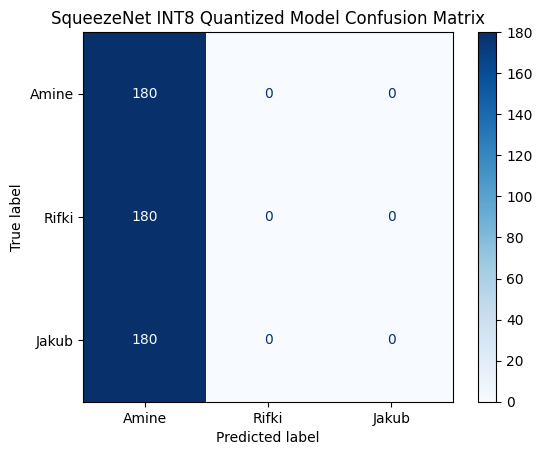

In [18]:
disp = ConfusionMatrixDisplay(confusion_matrix=quant_cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', values_format='d')
plt.title('SqueezeNet INT8 Quantized Model Confusion Matrix')
plt.show()
